In [1]:
# import all needful libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


**DATA SOURCING**

In [3]:
dff = pd.read_csv('/content/drive/MyDrive/Telco_churn_EDA_dataset/Copy of WA_Fn-UseC_-Telco-Customer-Churn.csv')

df = dff.copy()

**DATA PRE-CHECKING**

In [4]:
df.shape

(7043, 21)

In [5]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
# check the duplicated rows
df.duplicated().sum()

np.int64(0)

- this dataset doesn't hold any duplicated rows

In [8]:
# check the columns
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [9]:
# STANDARDIZE COLUMNS NAMES

# Convert PascalCase to snake_case and standardize
df.columns = df.columns.str.replace(r'([a-z0-9])([A-Z])', r'\1_\2', regex=True).str.lower().str.strip()

df.columns

Index(['customer_id', 'gender', 'senior_citizen', 'partner', 'dependents',
       'tenure', 'phone_service', 'multiple_lines', 'internet_service',
       'online_security', 'online_backup', 'device_protection', 'tech_support',
       'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing',
       'payment_method', 'monthly_charges', 'total_charges', 'churn'],
      dtype='object')

**DATA CLEANING**

Before performing Exploratory Data Analysis, the dataset is cleaned to ensure data quality and consistency. This includes identifying missing values, correcting data types, standardizing column names, validating records, and preparing features for reliable analysis.

In [10]:
# Handles missing values


# check is there any missings (both empty space or NULL) values are there
for col in df.columns:
  if df[col].isnull().sum() > 0: #checking NULL values
    print(f"{col} has {df[col].isnull().sum()} missing values")
  if df[df[col]==' '].shape[0] > 0: # checking empty white space values
    print(f"{col} has {df[df[col]==' '].shape[0]} blank rows")

total_charges has 11 blank rows


there's 11 rows which has empty in total_charges column

In [11]:
# check again is there any null values in the dataset
df.isnull().sum()

,0
customer_id,0
gender,0
senior_citizen,0
partner,0
dependents,0
tenure,0
phone_service,0
multiple_lines,0
internet_service,0
online_security,0


In [12]:
# convert numaric value columns into int/float data type

df['total_charges'] = pd.to_numeric(df['total_charges'], errors='coerce')
df['monthly_charges'] = pd.to_numeric(df['monthly_charges'], errors='coerce')
df['tenure'] = pd.to_numeric(df['tenure'], errors='coerce')

In [13]:
df.dtypes

,0
customer_id,object
gender,object
senior_citizen,int64
partner,object
dependents,object
tenure,int64
phone_service,object
multiple_lines,object
internet_service,object
online_security,object


In [14]:
# convert the empty space rows into NULL

df.replace(r'^\s*$', pd.NA, regex=True, inplace=True) # replace all empty strings and whitespaces with NULL


- basically we are not sure about specifically how much blank spaces are there, i mean exactly, so this line of code replace if a cell contain a single and some other cells contian more than one or two blank spaces into NULL.

In [15]:
df.isnull().sum()

,0
customer_id,0
gender,0
senior_citizen,0
partner,0
dependents,0
tenure,0
phone_service,0
multiple_lines,0
internet_service,0
online_security,0


- total_charges column having 11 rows which are NULL values

In [16]:
# check the distribution of NULL values in whole dataset

round(df['total_charges'].isnull().sum() / len(df)*100,2)

np.float64(0.16)

- Only 11 records (~0.16%) had missing values in Total Charges. Since the percentage was negligible and Total Charges is a derived financial metric, those records were removed to maintain analytical integrity.
- basically when Tenure is 0, then Total Charges become NULL values, but we cannot impute those NULL values with Monthly Charges. so its better to delete those rows

In [17]:
# lets check those 11 rows which has either 'tenure' as zero or 'total_charges is NULL

df[(df['total_charges'].isnull()) | (df['tenure']==0)][['tenure', 'monthly_charges', 'total_charges']]

,tenure,monthly_charges,total_charges
488,0,52.55,NaN
753,0,20.25,NaN
936,0,80.85,NaN
1082,0,25.75,NaN
1340,0,56.05,NaN
3331,0,19.85,NaN
3826,0,25.35,NaN
4380,0,20.00,NaN
5218,0,19.70,NaN
6670,0,73.35,NaN


In [18]:
# lets check normal distribution in 'total_charges' columns where 'tenure' is not zero

df[~(df['total_charges'].isnull()) | ~(df['tenure']==0)][['tenure', 'monthly_charges', 'total_charges']].tail(10)

,tenure,monthly_charges,total_charges
7033,38,69.50,2625.25
7034,67,102.95,6886.25
7035,19,78.70,1495.10
7036,12,60.65,743.30
7037,72,21.15,1419.40
7038,24,84.80,1990.50
7039,72,103.20,7362.90
7040,11,29.60,346.45
7041,4,74.40,306.60
7042,66,105.65,6844.50


- so basically total_charges columns values are not exactly 'Monthly Charges' * 'Tenure',
  because we can see the variations in Total Charges values. maybe long loyal customers got some discounts or offer's as well as some customers got add on charges also as extra money.

- so it's better to remove those 11 rows instead of try to imputing

In [19]:
# delete the rows which contain and create a new variable for cleaned dataset
df_clean = df.dropna(subset='total_charges', axis=0)

In [20]:
df_clean.shape

(7032, 21)

- deleted those 11 rows

In [21]:
df_clean.head()

,customer_id,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,...,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [22]:
# convert 'senior_citizen' column values into categorical 'Yes' or 'No

df_clean['senior_citizen'] = df_clean['senior_citizen'].map({0: 'No', 1: 'Yes'})

In [23]:
# check the customer distribution of senior_citzen column

df_clean['senior_citizen'].value_counts(normalize=True).round(2)

,proportion
senior_citizen,
No,0.84
Yes,0.16


- almost 16% of our customers are senior citzens

In [24]:
df_clean.describe()

,tenure,monthly_charges,total_charges
count,7032.000000,7032.000000,7032.000000
mean,32.421786,64.798208,2283.300441
std,24.545260,30.085974,2266.771362
min,1.000000,18.250000,18.800000
25%,9.000000,35.587500,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.862500,3794.737500
max,72.000000,118.750000,8684.800000


In [25]:
# checking outliers


# IQR function to detection outliere on one-dimensional dataset
def find_anomalies(data):
  Q1 = data.quantile(0.25)
  Q3 = data.quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR
  outliers = data[(data < lower_bound) | (data > upper_bound)]
  return outliers


In [26]:
list_tenure = find_anomalies(df_clean['tenure'])
list_tenure

,tenure


- no anomalies

In [27]:
list_monthly_charges = find_anomalies(df_clean['monthly_charges'])
list_monthly_charges

,monthly_charges


- no anomalies

In [28]:
list_total_charges = find_anomalies(df_clean['total_charges'])
list_total_charges

,total_charges


- it's a clean dataset which has no outliers. it didn't carry any outliers in both tenure, monthly_charges, and total_charges columns.

In [29]:
# to check again the outliers in 'tenure' practically

tq1 = df_clean.tenure.quantile(0.25)
tq2 = df_clean.tenure.quantile(0.50)
tq3 = df_clean.tenure.quantile(0.75)

IQR = tq3-tq1
print(f"the IQR is  : {IQR}")
print(f"the Q1 value is : {tq1}")
print(f"the Q3 values is : {tq3}")
print(f"the tenure minimum valus is : {df_clean.tenure.min()}")
print(f"the tenure maximum value is : {df_clean.tenure.max()}")
print(f"the tenure lower bound outlier is : {tq1 - 1.5*IQR}")
print(f"the tenure upper bound outlier is : {tq3 + 1.5*IQR}")

the IQR is  : 46.0
the Q1 value is : 9.0
the Q3 values is : 55.0
the tenure minimum valus is : 1
the tenure maximum value is : 72
the tenure lower bound outlier is : -60.0
the tenure upper bound outlier is : 124.0


- tenure highest value is 72, but the upper bound oultier is 124. so no outlier
- tenure lowest value is 1, and the lower bound outlier is -60.none of any normal tenure value comes in negative value and if we consider this as zero also, there is no outlier
- no outlier in tenure column

In [30]:
# to check again the outliers in 'monthly_charges' practically

tq1 = df_clean.monthly_charges.quantile(0.25)
tq2 = df_clean.monthly_charges.quantile(0.50)
tq3 = df_clean.monthly_charges.quantile(0.75)

IQR = tq3-tq1
print(f"the IQR is  : {IQR}")
print(f"the Q1 value is : {tq1}")
print(f"the Q3 values is : {tq3}")
print(f"the monthly_charges minimum valus is : {df_clean.monthly_charges.min()}")
print(f"the monthly_charges maximum value is : {df_clean.monthly_charges.max()}")
print(f"the monthly_charges lower bound outlier is : {tq1 - 1.5*IQR}")
print(f"the monthly_charges upper bound outlier is : {tq3 + 1.5*IQR}")

the IQR is  : 54.275
the Q1 value is : 35.5875
the Q3 values is : 89.8625
the monthly_charges minimum valus is : 18.25
the monthly_charges maximum value is : 118.75
the monthly_charges lower bound outlier is : -45.824999999999996
the monthly_charges upper bound outlier is : 171.27499999999998


- Monthly Charges Highest value is 118.75, but the Upper bound oultier is 171.2. so No Outlier
- Monthly Charges Lowest value is 18.25, and the Lower bound outlier is -45.8. so No Outlier
- No Outlier in Monthly Charges column

In [31]:
# to check again the outliers in 'total_charges' practically

tq1 = df_clean.total_charges.quantile(0.25)
tq2 = df_clean.total_charges.quantile(0.50)
tq3 = df_clean.total_charges.quantile(0.75)

IQR = tq3-tq1
print(f"the IQR is  : {IQR}")
print(f"the Q1 value is : {tq1}")
print(f"the Q3 values is : {tq3}")
print(f"the total_charges minimum valus is : {df_clean.total_charges.min()}")
print(f"the total_charges maximum value is : {df_clean.total_charges.max()}")
print(f"the total_charges lower bound outlier is : {tq1 - 1.5*IQR}")
print(f"the total_charges upper bound outlier is : {tq3 + 1.5*IQR}")

the IQR is  : 3393.2875000000004
the Q1 value is : 401.45
the Q3 values is : 3794.7375
the total_charges minimum valus is : 18.8
the total_charges maximum value is : 8684.8
the total_charges lower bound outlier is : -4688.481250000001
the total_charges upper bound outlier is : 8884.66875


- Total Charges Highest value is 8684.8, but the Upper bound Oultier is 8884.66. so No Outlier
- Total Charges Lowest value is 18.8, and the Lower bound Outlier is -4688.4. so No Outlier
- No Outlier in Total Charges column

- Numarical columns ('tenure', 'monthly_charges', 'total_charges') are clean and reliable


In [32]:
df_clean.describe()

,tenure,monthly_charges,total_charges
count,7032.000000,7032.000000,7032.000000
mean,32.421786,64.798208,2283.300441
std,24.545260,30.085974,2266.771362
min,1.000000,18.250000,18.800000
25%,9.000000,35.587500,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.862500,3794.737500
max,72.000000,118.750000,8684.800000


In [33]:
df_clean.head()

,customer_id,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,...,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [34]:
# Let's check is there any Invalid values in any columns, and lets see each columns unique values too

for col in df_clean.columns.drop('customer_id'):
  print(f"{col} : {df_clean[col].unique()}\n")


gender : ['Female' 'Male']

senior_citizen : ['No' 'Yes']

partner : ['Yes' 'No']

dependents : ['No' 'Yes']

tenure : [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26 39]

phone_service : ['No' 'Yes']

multiple_lines : ['No phone service' 'No' 'Yes']

internet_service : ['DSL' 'Fiber optic' 'No']

online_security : ['No' 'Yes' 'No internet service']

online_backup : ['Yes' 'No' 'No internet service']

device_protection : ['No' 'Yes' 'No internet service']

tech_support : ['No' 'Yes' 'No internet service']

streaming_tv : ['No' 'Yes' 'No internet service']

streaming_movies : ['No' 'Yes' 'No internet service']

contract : ['Month-to-month' 'One year' 'Two year']

paperless_billing : ['Yes' 'No']

payment_method : ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']

monthly_charges : 

In [35]:
# create 'tenure_bin' (year-wise) column basis on 'tenure' column

df_clean['tenure_bin'] = pd.cut(
    df_clean['tenure'],
    bins=[0, 12, 24, 36, 48, 60, 72],
    labels=['0-12', '13-24', '25-36', '37-48', '49-60', '61-72']
)

In [36]:
df_clean['tenure_bin'].value_counts().sort_index()

,count
tenure_bin,
0-12,2175
13-24,1024
25-36,832
37-48,762
49-60,832
61-72,1407


- 20% of our customers with us more than 5 year, they are loyal with us

In [37]:
df_clean.shape

(7032, 22)

In [38]:
# beofore start to doing Churn analysis, lets remove the 'customer_id' column.
df_clean.drop('customer_id', axis=1, inplace=True)

In [39]:
df_clean.columns

Index(['gender', 'senior_citizen', 'partner', 'dependents', 'tenure',
       'phone_service', 'multiple_lines', 'internet_service',
       'online_security', 'online_backup', 'device_protection', 'tech_support',
       'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing',
       'payment_method', 'monthly_charges', 'total_charges', 'churn',
       'tenure_bin'],
      dtype='object')

**DATA EXPLORATION**

**UNIVARIATE ANALYSIS**

In [40]:
# before start to doing UNIVARIATE ANALYSIS,
# create variabel which carry our dataset categorical value columns only


cat_cols = df_clean.select_dtypes(include=['object','category']).columns
cat_cols

Index(['gender', 'senior_citizen', 'partner', 'dependents', 'phone_service',
       'multiple_lines', 'internet_service', 'online_security',
       'online_backup', 'device_protection', 'tech_support', 'streaming_tv',
       'streaming_movies', 'contract', 'paperless_billing', 'payment_method',
       'churn', 'tenure_bin'],
      dtype='object')

In [41]:
len(cat_cols)

18

In [42]:
# columns which are not hold categorical values

df_clean.columns.difference(cat_cols)

Index(['monthly_charges', 'tenure', 'total_charges'], dtype='object')

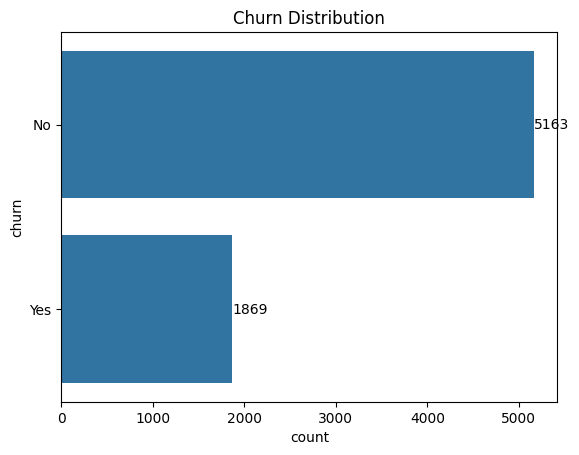

In [43]:
# lets see the churned customers count from whole dataset

ak = sns.countplot(df_clean['churn'])
ak.bar_label(ak.containers[0])
plt.title(f'Churn Distribution')
plt.show()

- around 27% customers are churned. so each 1/4th customer tends to churn

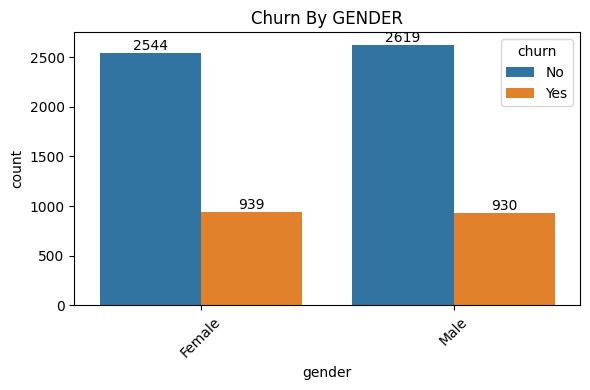

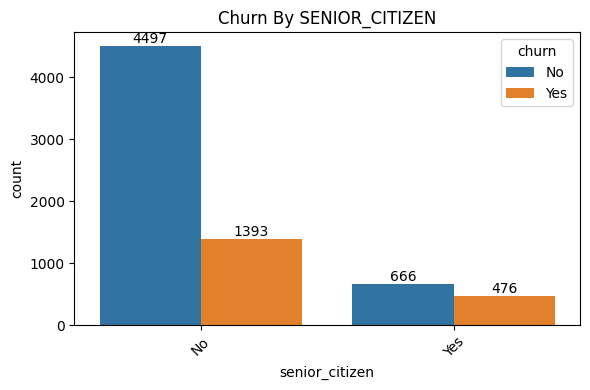

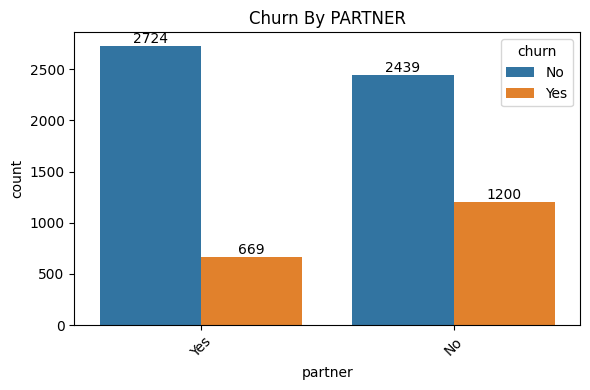

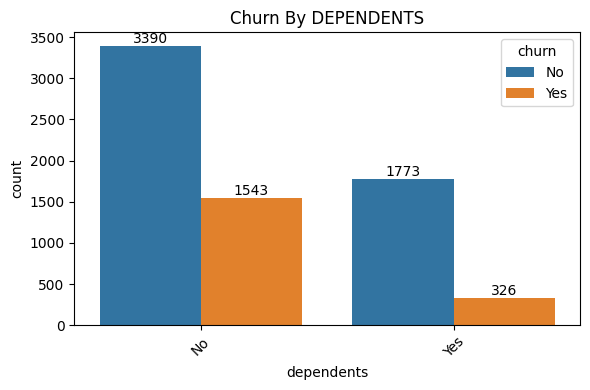

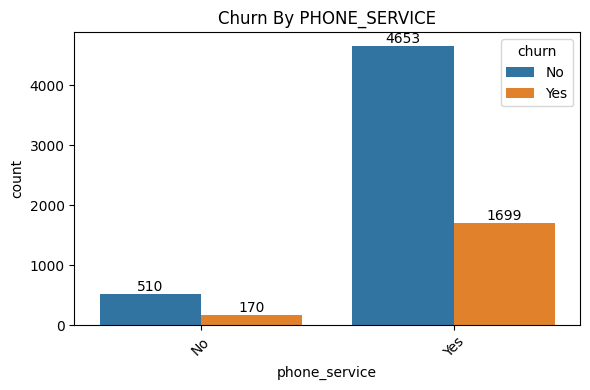

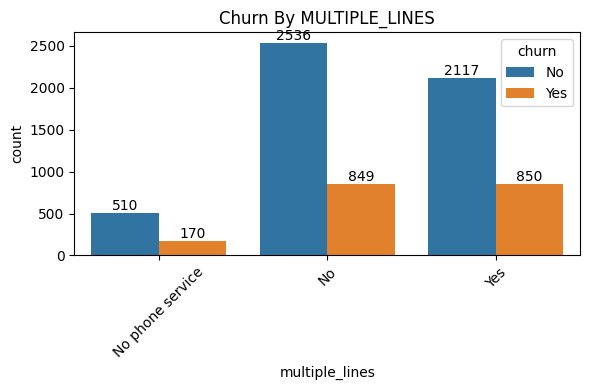

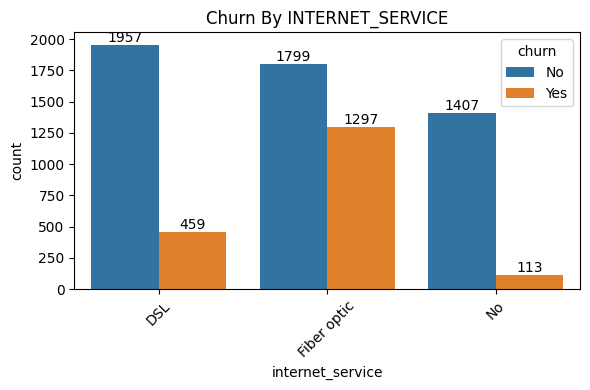

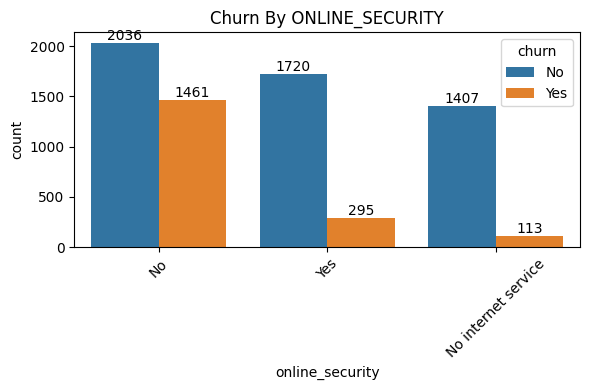

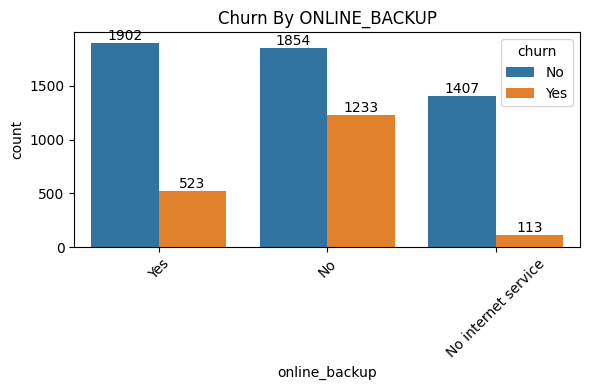

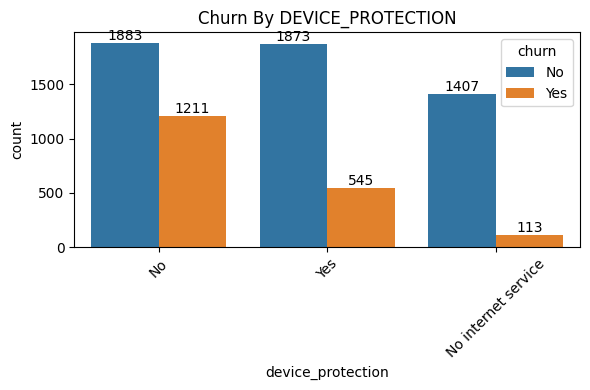

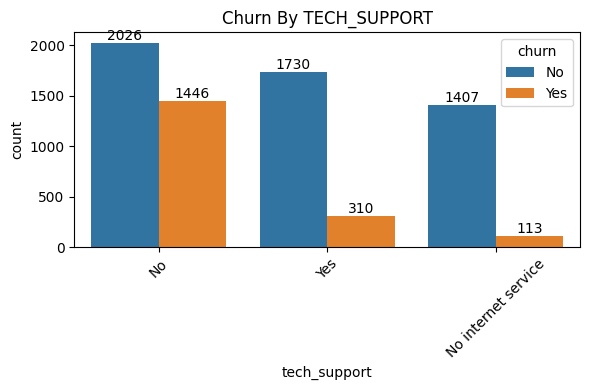

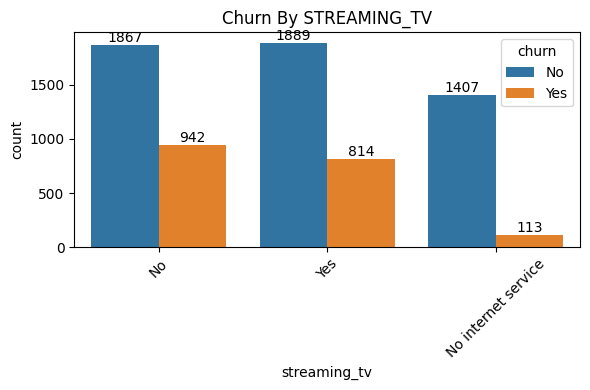

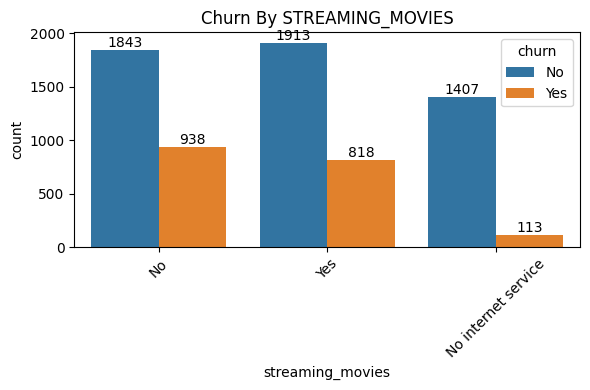

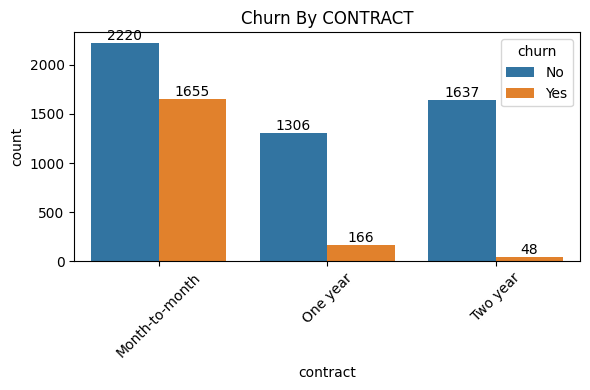

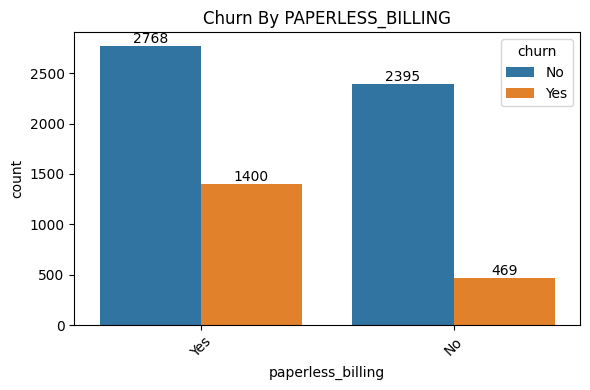

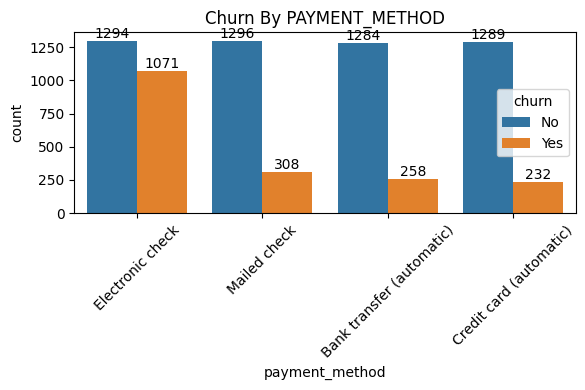

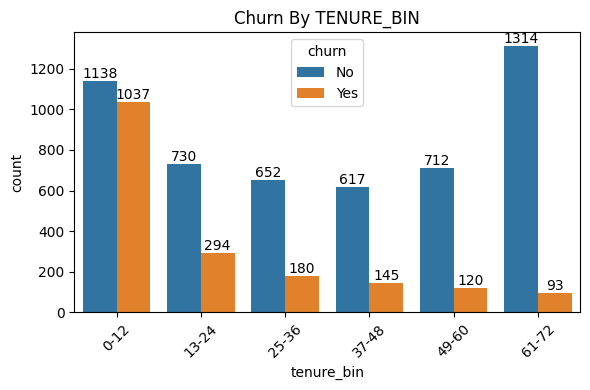

In [44]:
for i, predictor in enumerate(cat_cols.drop('churn')):
  plt.figure(i, figsize=(6,4))
  ax = sns.countplot(data=df_clean, x=predictor, hue='churn')

  # for provide datalabels for each
  for container in ax.containers:
    ax.bar_label(container, fmt='%d')


  plt.title(f"Churn By {predictor.upper()}")  #provide headings for each visual
  plt.xticks(rotation=45)
  plt.tight_layout()
  plt.show()

KEY INSIGHTS :-  


• 	*Gender* → Churn rate is almost equal between male and female customers. Gender is not a strong churn driver.

• 	*Senior Citizen* → Senior citizens are more likely to churn compared to younger customers.

• 	*Partner* → Customers without partners are more likely to churn.

• 	*Dependents* → Customers without dependents are more likely to churn.

• 	*Phone Service* → Churn rates are nearly equal between customers with and
without phone service. This variable is not a strong driver.

• 	*Multiple Lines* → Customers with multiple lines show a slightly higher churn rate, but the difference is weak.

• 	*Internet Service* → Customers using fiber optic internet are more likely to churn compared to DSL or no internet service.

• 	*Online Security* → Customers without online security are more likely to churn.

• 	*Online Backup* → Customers without online backup are more likely to churn.

• 	*Device Protection* → Customers without device protection are more likely to churn.

• 	*Tech Support* → Customers without tech support are more likely to churn.

• 	*Streaming TV* → Customers with streaming TV are slightly more likely to churn (linked to fiber optic usage).

• 	*Streaming Movies* → Customers with streaming movies are slightly more likely to churn (linked to fiber optic usage).

• 	*Contract* → Month‑to‑month contract customers are most likely to churn. Two‑year contract customers are least likely to churn.

• 	*Paperless Billing* → Customers using paperless billing are more likely to churn.

• 	*Payment Method* → Customers paying via electronic check are more likely to churn compared to other payment methods.

• 	*Tenure Bins* → Customers in the 0-12 month tenure bin have the highest churn rate (48%), while customers in the 61–72 month tenure bin have the lowest churn rate (~7%). Overall, churn decreases steadily as tenure increases, showing that long‑tenure customers are more stable.

• 	**Strong churn drivers**: Senior citizen, no partner, no dependents, fiber optic internet, lack of add‑on services (security, backup, protection, tech support), month‑to‑month contracts, paperless billing, electronic check payment, tenure bins (early‑tenure) customers churn

• 	**Weak churn drivers**: Multiple lines, streaming services(steaming_tv, streaming_movies).

• 	**No effect**: Gender, phone service


**NUMARICAL ANALYSIS**

In [45]:
# lets check all the numarical columns we have
df_clean.dtypes

df_clean.select_dtypes(include=['int64','float64']).columns

Index(['tenure', 'monthly_charges', 'total_charges'], dtype='object')

In [46]:
df_clean.describe()

,tenure,monthly_charges,total_charges
count,7032.000000,7032.000000,7032.000000
mean,32.421786,64.798208,2283.300441
std,24.545260,30.085974,2266.771362
min,1.000000,18.250000,18.800000
25%,9.000000,35.587500,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.862500,3794.737500
max,72.000000,118.750000,8684.800000


- **Tenure** : Most customers stay around 2–3 years, but some leave very early (1 month) while some stay the full 6 years.

- **Monthly Charges** : Charges are spread widely. Half of customers pay less than ~70, but some pay close to 120. This shows a broad pricing structure.

- **Total Charges** : Big gap between mean and median → distribution is skewed. Many customers have low total charges (short tenure), while a smaller group accumulates very high charges (long tenure).

In [47]:
# lets check the correlation between the Monthly charges and Total charges

df_clean['monthly_charges'].corr(df_clean['total_charges']).round(1)

np.float64(0.7)

- Total charges increases as Monthly charges increase
- Monthly charges and Total charges are positevely correlated. that's mean to getting high total charges can be by getting high monthly charges too.

In [48]:
# we have to create a variable which contain only Churned customers details

churned_cus_data = df_clean[df_clean['churn']=='Yes']
churned_cus_data.shape[0]  # churned customers numbers of rows

1869

In [49]:
# we have to create a variable which contain only Existing customers details

active_cus_data = df_clean[df_clean['churn']=='No']
active_cus_data.shape[0]  # Existing customers number of rows

5163

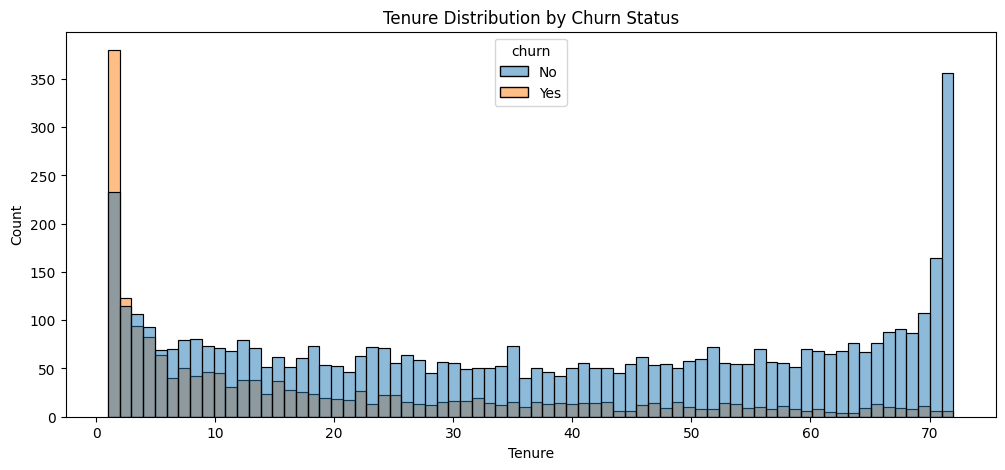

In [66]:
plt.figure(figsize=(12,5))
sns.histplot(x='tenure', data=df_clean, bins=72, hue='churn')
plt.title('Tenure Distribution by Churn Status')
plt.xlabel('Tenure')
plt.ylabel('Count')
plt.show()

insight:

* people who have used our sercice for long time have stayed and people who have used our sevice 1 or 2 months have churned.

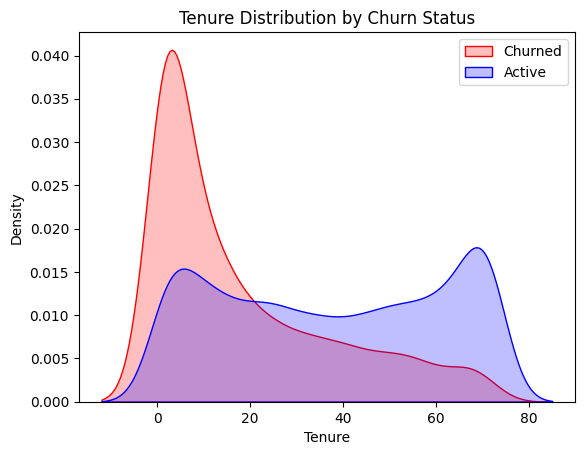

In [50]:
# lets see visually, Churned and Active customers Density and Distribution in Tenure column

ten = sns.kdeplot(data=churned_cus_data, x='tenure',
                  fill=True, color='red')

ten = sns.kdeplot(data=active_cus_data, x='tenure',
                  fill= True, color='blue')

ten.legend(['Churned', 'Active'], loc='upper right')
ten.set_xlabel('Tenure')
ten.set_ylabel('Density')
ten.set_title('Tenure Distribution by Churn Status')
plt.show()

- Customers with short tenure are far more likely to churn, while customers with long tenure(customers who stayed more than 20 months) are more stable and loyal.

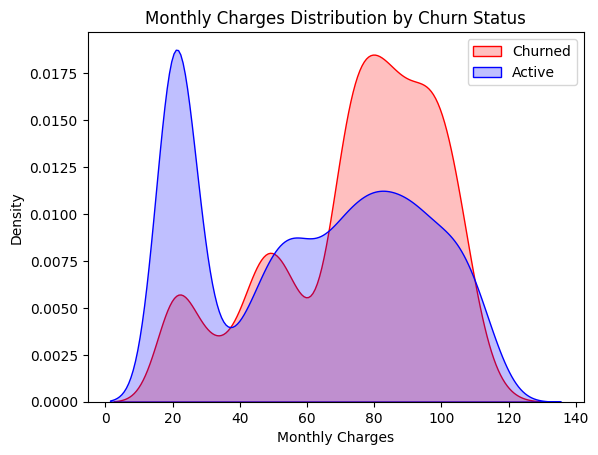

In [51]:
# lets see visually, Churned and Active customers Density and Distribution in Monthly Charges column

mth = sns.kdeplot(data=churned_cus_data, x='monthly_charges',
                  fill=True, color='red')

mth = sns.kdeplot(data=active_cus_data, x='monthly_charges',
                  ax=mth,fill= True, color='blue')

mth.legend(['Churned', 'Active'], loc='upper right')
mth.set_title('Monthly Charges Distribution by Churn Status')
mth.set_xlabel('Monthly Charges')
mth.set_ylabel('Density')
plt.show()


- Higher monthly charges are associated with higher churn risk. Customers paying more are more likely to leave, while lower‑charge customers are more stable.

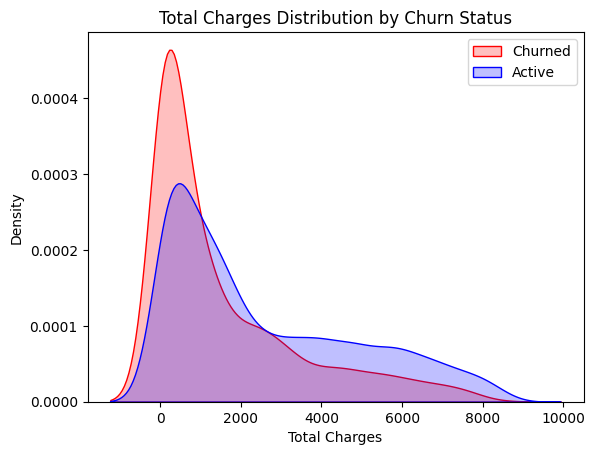

In [52]:
# lets see visually, Churned and Active customers Density and Distribution in Total Charges column

tot = sns.kdeplot(data=churned_cus_data, x='total_charges',
                  fill=True, color='red')

tot = sns.kdeplot(data=active_cus_data, x='total_charges',
                  ax=tot, fill=True, color='blue')

tot.legend(['Churned', 'Active'], loc='upper right')
tot.set_title('Total Charges Distribution by Churn Status')
tot.set_xlabel('Total Charges')
tot.set_ylabel('Density')
plt.show()

- surprising insight -> as higher churn at lower Total Charges
- This is a strong lifecycle signal: early‑stage customers are at highest risk of churn.
- Customers with low total charges are far more likely to churn, while customers who have stayed longer and paid more are much less likely to churn.

-> However, if we combine the insights of 3 parameters that is, 'Tenure', 'Monthly Charges', 'Total Charges', then the pictures are bit clear
  - Higher Monthly charge at Lower Tenure results into Lower Total Charge.
  
**All these 3 factors viz Higher Monthly Charge, Lower Tenure, and Lower Total Charge are linked to High Churn**.

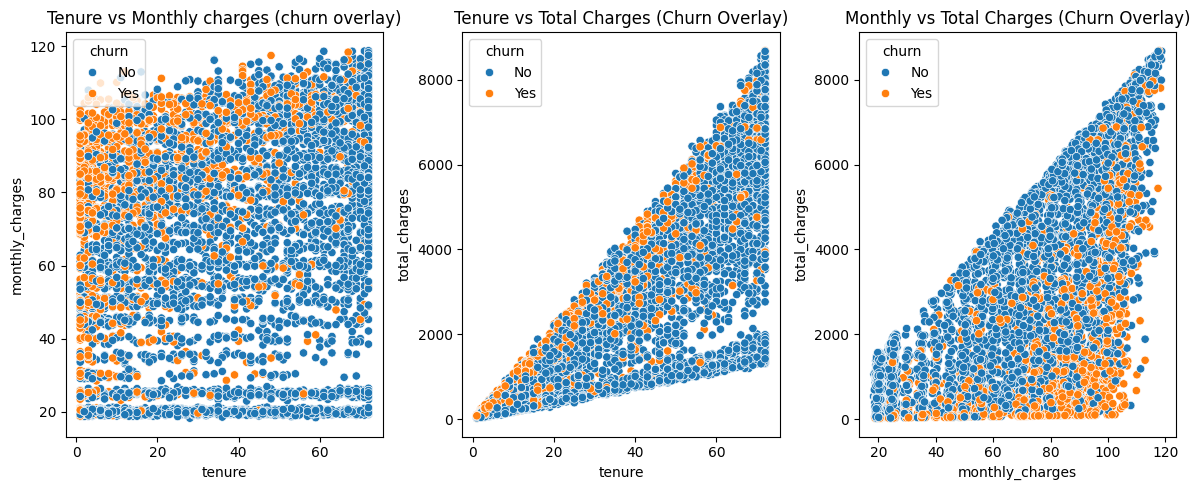

In [53]:
# lets check the visual correlation of each numarical columns

plt.figure(figsize=(12,5))

plt.subplot(1,3,1)
sns.scatterplot(data=df_clean, x='tenure', y='monthly_charges', hue='churn')
plt.title("Tenure vs Monthly charges (churn overlay)")

plt.subplot(1,3,2)
sns.scatterplot(data=df_clean, x='tenure', y='total_charges', hue='churn')
plt.title("Tenure vs Total Charges (Churn Overlay)")

plt.subplot(1,3,3)
sns.scatterplot(data=df_clean, x='monthly_charges', y='total_charges', hue='churn')
plt.title("Monthly vs Total Charges (Churn Overlay)")

plt.tight_layout()
plt.show()


- *Tenure vs Monthly Charges:*

Customers with short tenure churn the most, especially those paying higher monthly charges; long‑tenure customers remain stable even at higher charges.we can't find any relationship with Tenure and Monthly charges.

- *Tenure vs Total Charges:*

Churn is concentrated among customers with low tenure and low total charges, while long‑tenure customers with high accumulated charges show very low churn.Tenure and Total charges are positevely correlated.

- *Monthly Charges vs Total Charges:*

New customers on expensive plans (high monthly charges but low total charges) churn heavily, whereas long‑tenure customers with high total charges are loyal regardless of monthly charges.

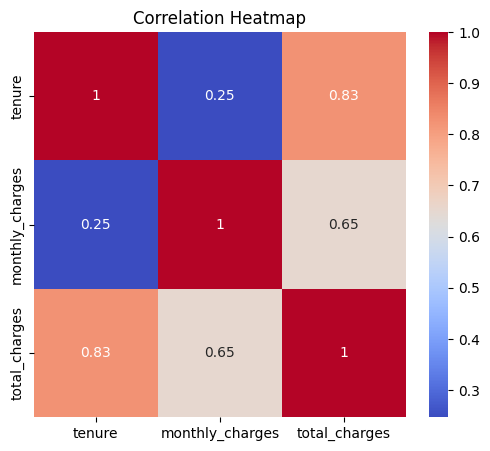

In [54]:
plt.figure(figsize=(6,5))
sns.heatmap(df_clean[['tenure', 'monthly_charges', 'total_charges']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

- **Tenure vs. Total Charges** → 0.83 (Strong Positive Correlation)

Customers who stay longer naturally accumulate higher total charges. This is expected because total charges = monthly charges × tenure (roughly).

- **Monthly Charges vs. Total Charges** → 0.65 (Moderate Positive Correlation)

Customers with higher monthly charges tend to have higher total charges, but tenure also plays a role. A short‑tenure customer with high monthly charges may still have low total charges.

- **Tenure vs. Monthly Charges** → 0.25 (Weak Positive Correlation)

Tenure doesn’t strongly influence monthly charges. Pricing is more dependent on the plan chosen, not how long the customer has stayed.

**BIVARIATE ANALYSIS**


In [55]:
len(df_clean)

7032

In [56]:
len(churned_cus_data)

1869

In [57]:
df_clean.columns

Index(['gender', 'senior_citizen', 'partner', 'dependents', 'tenure',
       'phone_service', 'multiple_lines', 'internet_service',
       'online_security', 'online_backup', 'device_protection', 'tech_support',
       'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing',
       'payment_method', 'monthly_charges', 'total_charges', 'churn',
       'tenure_bin'],
      dtype='object')

In [58]:
# we have to create a function for plotting Bivariate analysing visual


# =============================================================================
# Category Orders (used for consistent plotting)
# =============================================================================

value_orders = {
    'gender': ['Female', 'Male'],
    'senior_citizen': ['No', 'Yes'],
    'partner': ['No', 'Yes'],
    'dependents': ['No', 'Yes'],
    'phone_service': ['No', 'Yes'],
    'multiple_lines': ['No phone service', 'No', 'Yes'],
    'internet_service': ['DSL', 'Fiber optic', 'No'],
    'online_security': ['No internet service', 'No', 'Yes'],
    'online_backup': ['No internet service', 'No', 'Yes'],
    'device_protection': ['No internet service', 'No', 'Yes'],
    'tech_support': ['No internet service', 'No', 'Yes'],
    'streaming_tv': ['No internet service', 'No', 'Yes'],
    'streaming_movies': ['No internet service', 'No', 'Yes'],
    'contract': ['Month-to-month', 'One year', 'Two year'],
    'paperless_billing': ['No', 'Yes'],
    'payment_method': [
        'Electronic check',
        'Mailed check',
        'Bank transfer (automatic)',
        'Credit card (automatic)'
    ],
    'tenure_bin': [
        '0-12',
        '13-24',
        '25-36',
        '37-48',
        '49-60',
        '61-72'
    ]
}


def plot_bivariate(df_clean,
                   churned_cus_data,
                   x_col,
                   category_orders = value_orders,
                   target='churn',
                   figsize=(12,4),
                   rotation=20):
    """
    --------------------------------------------------------------------
    Plot one categorical variable against every other categorical variable.

    Parameters
    ----------
    df_all : Full cleaned dataset

    df_churn : Churned customers dataset

    x_col : Primary categorical variable

    category_orders : Dictionary containing category orders

    target : Target column (default='churn')
    --------------------------------------------------------------------
    """

    cat_cols = df_clean.select_dtypes(
        include=['object', 'category']).columns

    compare_cols = [
        c for c in cat_cols
        if c not in [x_col, target]
    ]

    for hue_col in compare_cols:

        fig, axes = plt.subplots(
            1,
            2,
            figsize=figsize
        )

        # ==========================================================
        # All Customers
        # ==========================================================

        sns.countplot(
            data=df_clean,
            x=x_col,
            hue=hue_col,
            order= category_orders.get(x_col),
            hue_order= category_orders.get(hue_col),
            ax=axes[0]
        )

        axes[0].set_title(
            f'All Customers by {x_col.replace("_"," ").title().upper()} '
            f'and {hue_col.replace("_"," ").title().upper()}'
        )

        axes[0].tick_params(
            axis='x',
            rotation=rotation
        )

        for container in axes[0].containers:
            axes[0].bar_label(
                container,
                fmt='%d',
                fontsize=8
            )

        # ==========================================================
        # Churned Customers
        # ==========================================================

        sns.countplot(
            data=churned_cus_data,
            x=x_col,
            hue=hue_col,
            order=category_orders.get(x_col),
            hue_order=category_orders.get(hue_col),
            ax=axes[1]
        )

        axes[1].set_title(
            f'Churned Customers by {x_col.replace("_"," ").title().upper()} '
            f'and {hue_col.replace("_"," ").title().upper()}'
        )

        axes[1].tick_params(
            axis='x',
            rotation=rotation
        )

        for container in axes[1].containers:
            axes[1].bar_label(
                container,
                fmt='%d',
                fontsize=8
            )

        plt.tight_layout()
        plt.show()

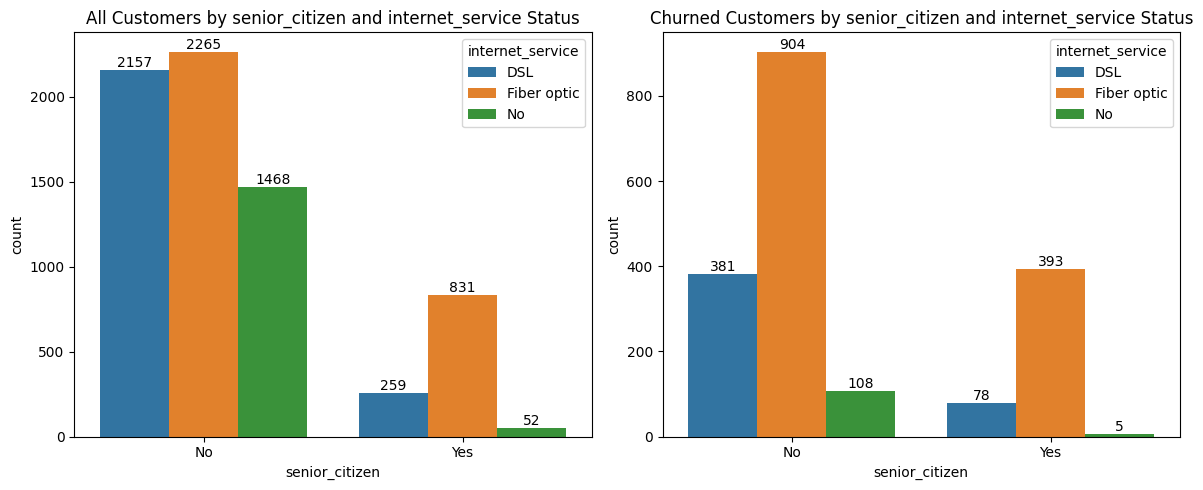

In [59]:
# SENIOR CITIZEN X INTERNET SERVICE

fig, axes = plt.subplots(1, 2, figsize=(12, 5)) # Create 1 row, 2 columns of subplots

# 1st plot
sns.countplot(data=df_clean, x='senior_citizen', hue='internet_service', order=['No','Yes'], hue_order=['DSL', 'Fiber optic', 'No'], ax=axes[0])
axes[0].set_title('All Customers by senior_citizen and internet_service Status')

# for provide datalabels for each
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%d')

# 2nd plot
sns.countplot(data=churned_cus_data, x='senior_citizen', hue='internet_service',order=['No','Yes'], hue_order=['DSL', 'Fiber optic', 'No'], ax=axes[1])
axes[1].set_title('Churned Customers by senior_citizen and internet_service Status')

# for provide datalabels for each
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%d')

plt.tight_layout() # Adjust subplot parameters for a tight layout
plt.show()

Insight:-
  - Senior citizens using fiber optic service churn the most compared to all other groups, while non-senior DSL users churn far less—showing that both age and internet service type strongly influence retention.

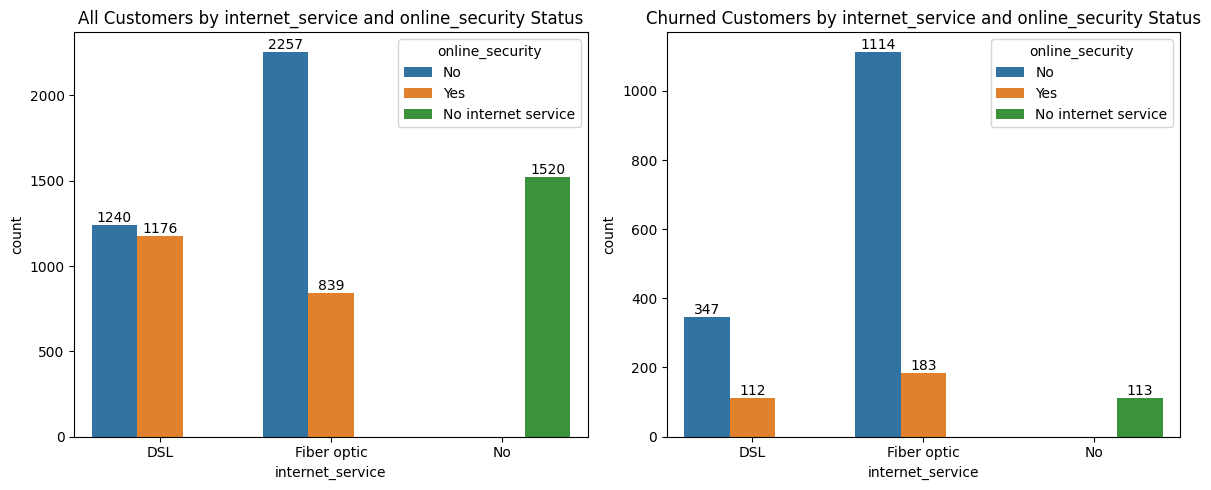

In [60]:
# INTERNET SERVICE X ONLINE SECURITY

fig, axes = plt.subplots(1, 2, figsize=(12, 5)) # Create 1 row, 2 columns of subplots

# 1st plot
sns.countplot(data=df_clean, x='internet_service', hue='online_security', order=['DSL', 'Fiber optic', 'No'], hue_order=['No', 'Yes', 'No internet service'] , ax=axes[0])
axes[0].set_title('All Customers by internet_service and online_security Status')

# for provide datalabels for each
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%d')

# 2nd plot
sns.countplot(data=churned_cus_data, x='internet_service', hue='online_security',order=['DSL', 'Fiber optic', 'No'], hue_order=['No', 'Yes', 'No internet service'] , ax=axes[1])
axes[1].set_title('Churned Customers by internet_service and online_security Status')

# for provide datalabels for each
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%d')

plt.tight_layout() # Adjust subplot parameters for a tight layout
plt.show()

Insight:-
  - Fiber optic customers without online security churn the most, while DSL customers with online security churn far less—showing that both internet service type and security features play a critical role in retention.

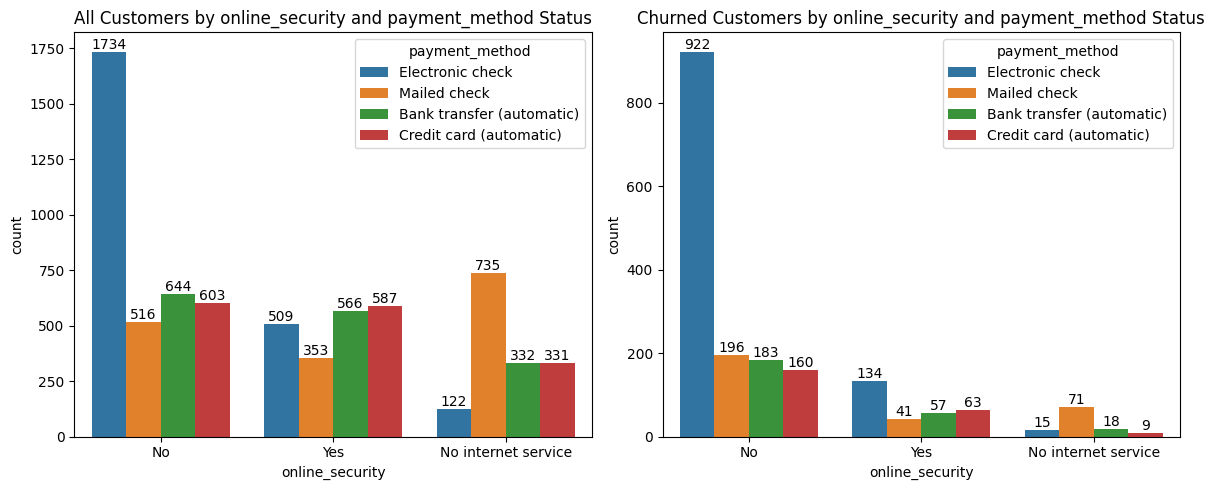

In [61]:
# ONLINE SECURITY X PAYMENT METHOD

fig, axes = plt.subplots(1, 2, figsize=(12, 5)) # Create 1 row, 2 columns of subplots

# 1st plot
sns.countplot(data=df_clean, x='online_security', hue='payment_method', order=['No', 'Yes', 'No internet service'], hue_order=['Electronic check', 'Mailed check', 'Bank transfer (automatic)','Credit card (automatic)'], ax=axes[0])
axes[0].set_title('All Customers by online_security and payment_method Status')

# for provide datalabels for each
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%d')

# 2nd plot
sns.countplot(data=churned_cus_data, x='online_security', hue='payment_method', order=['No', 'Yes', 'No internet service'], hue_order=['Electronic check', 'Mailed check', 'Bank transfer (automatic)','Credit card (automatic)'], ax=axes[1])
axes[1].set_title('Churned Customers by online_security and payment_method Status')

# for provide datalabels for each
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%d')

plt.tight_layout() # Adjust subplot parameters for a tight layout
plt.show()


Insight:-
  - Customers without online security who pay by electronic check churn the most, while those with online security and automatic payments (bank transfer or credit card) show far lower churn—highlighting that both security features and payment method strongly influence retention.

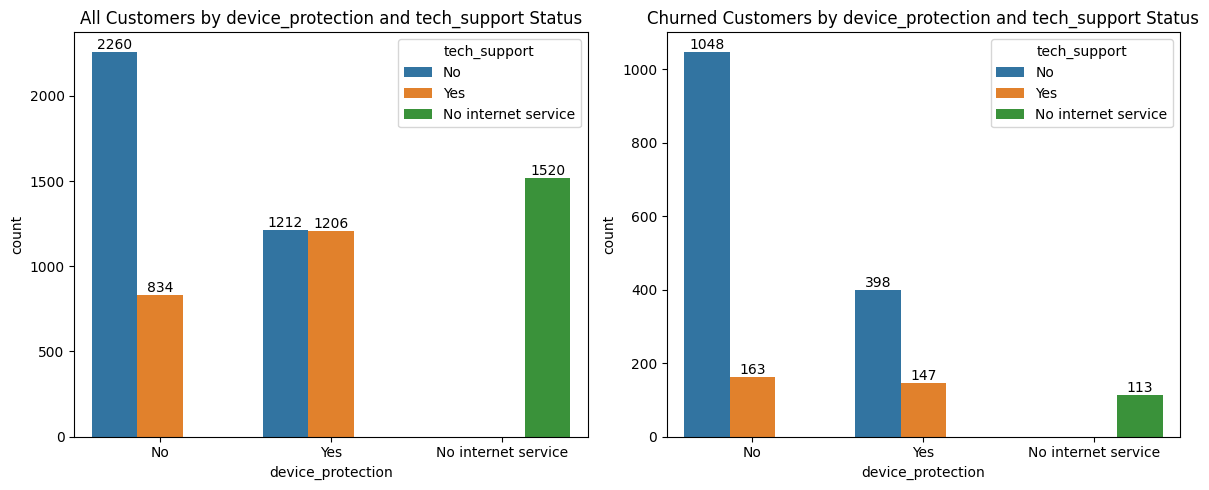

In [62]:
# DEVICE PROTECTION X TECH SUPPORT

fig, axes = plt.subplots(1, 2, figsize=(12, 5)) # Create 1 row, 2 columns of subplots

# 1st plot
sns.countplot(data=df_clean, x='device_protection', hue='tech_support', order=['No', 'Yes', 'No internet service'], hue_order=['No', 'Yes', 'No internet service'], ax=axes[0])
axes[0].set_title('All Customers by device_protection and tech_support Status')

# for provide datalabels for each
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%d')

# 2nd plot
sns.countplot(data=churned_cus_data, x='device_protection', hue='tech_support', order=['No', 'Yes', 'No internet service'], hue_order=['No', 'Yes', 'No internet service'], ax=axes[1])
axes[1].set_title('Churned Customers by device_protection and tech_support Status')

# for provide datalabels for each
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%d')

plt.tight_layout() # Adjust subplot parameters for a tight layout
plt.show()


Insight:-
  - Customers without device protection and without technical support churn the most, while those with both device protection and technical support show far lower churn—indicating that bundled support services significantly improve retention.

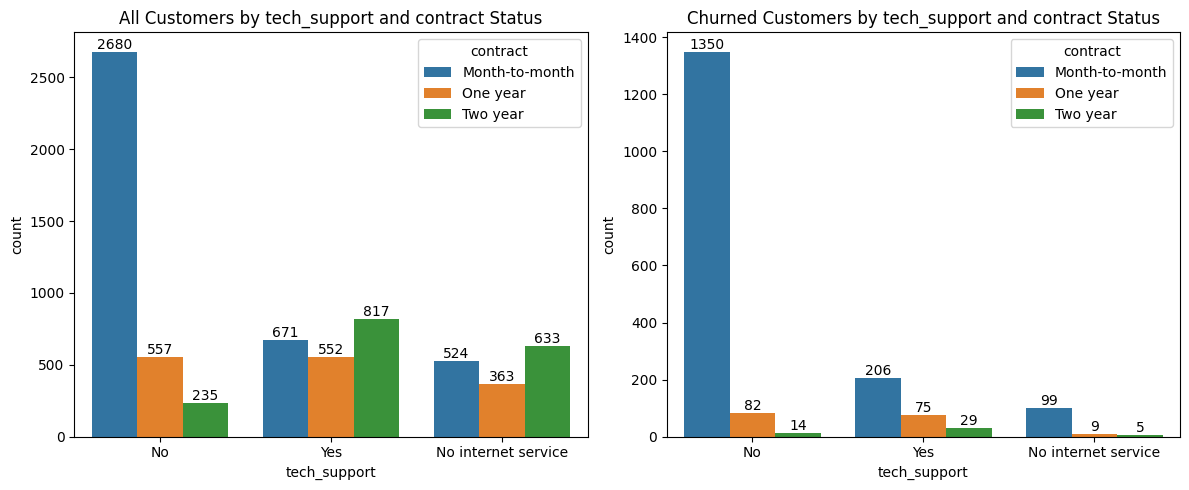

In [63]:
# TECH SUPPORT X CONTRACT

fig, axes = plt.subplots(1, 2, figsize=(12, 5)) # Create 1 row, 2 columns of subplots

# 1st plot
sns.countplot(data=df_clean, x='tech_support', hue='contract', order=['No', 'Yes', 'No internet service'], hue_order=['Month-to-month', 'One year', 'Two year'] , ax=axes[0])
axes[0].set_title('All Customers by tech_support and contract Status')

# for provide datalabels for each
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%d')

# 2nd plot
sns.countplot(data=churned_cus_data, x='tech_support', hue='contract', order=['No', 'Yes', 'No internet service'], hue_order=['Month-to-month', 'One year', 'Two year'] , ax=axes[1])
axes[1].set_title('Churned Customers by tech_support and contract Status')

# for provide datalabels for each
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%d')

plt.tight_layout() # Adjust subplot parameters for a tight layout
plt.show()

Insight:-
  - Month-to-month customers without technical support churn the most, while customers on one- or two-year contracts with technical support show far lower churn—highlighting that both longer contracts and support availability are key drivers of retention.

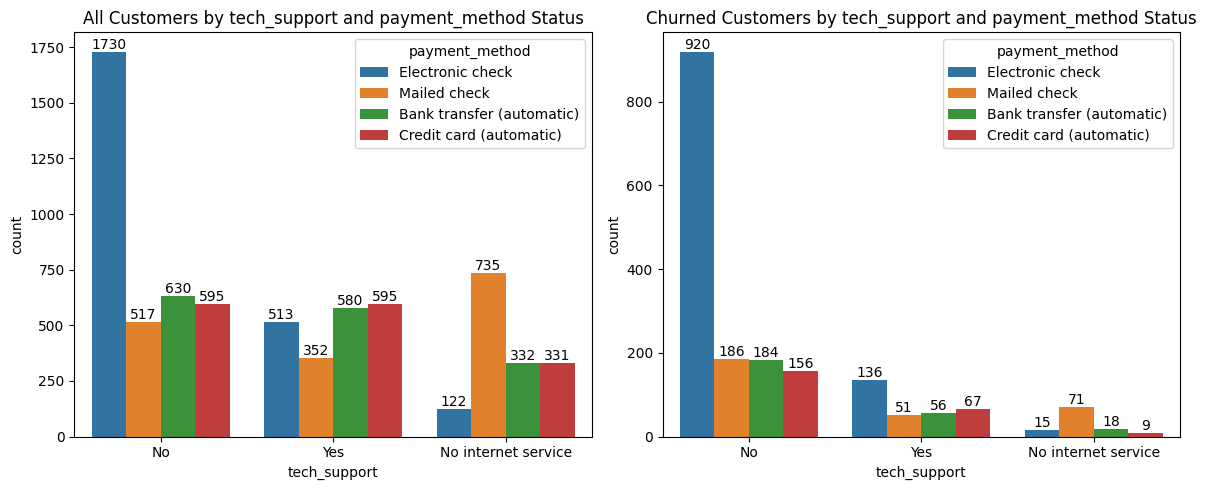

In [64]:
# TECH SUPPORT X PAYMENT METHORD

fig, axes = plt.subplots(1, 2, figsize=(12, 5)) # Create 1 row, 2 columns of subplots

# 1st plot
sns.countplot(data=df_clean, x='tech_support', hue='payment_method', order=['No', 'Yes', 'No internet service'], hue_order=['Electronic check', 'Mailed check', 'Bank transfer (automatic)','Credit card (automatic)'], ax=axes[0])
axes[0].set_title('All Customers by tech_support and payment_method Status')

# for provide datalabels for each
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%d')

# 2nd plot
sns.countplot(data=churned_cus_data, x='tech_support', hue='payment_method', order=['No', 'Yes', 'No internet service'], hue_order=['Electronic check', 'Mailed check', 'Bank transfer (automatic)','Credit card (automatic)'], ax=axes[1])
axes[1].set_title('Churned Customers by tech_support and payment_method Status')

# for provide datalabels for each
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%d')

plt.tight_layout() # Adjust subplot parameters for a tight layout
plt.show()


Insight:-
  - Customers without technical support who pay by electronic check churn the most, while those with technical support and automatic payments (bank transfer or credit card) show far lower churn, highlighting that both support availability and payment method strongly influence retention.


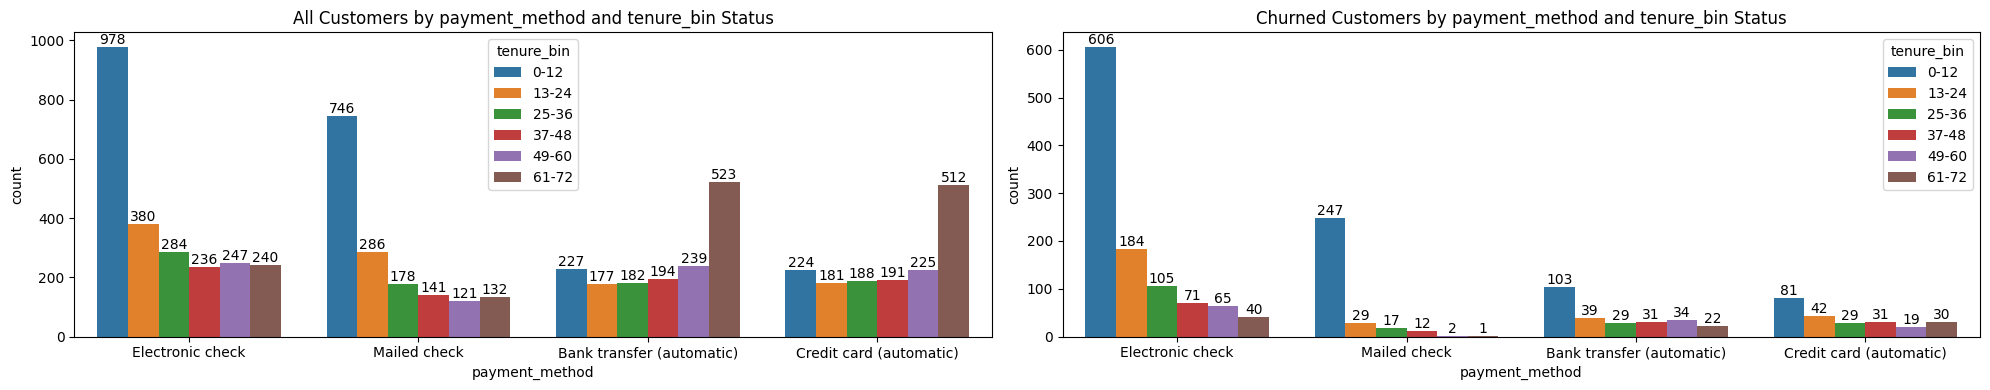

In [65]:
# PAYMENT METHOD X TENURE BINS

fig, axes = plt.subplots(1, 2, figsize=(20, 4)) # Create 1 row, 2 columns of subplots

# 1st plot
sns.countplot(data=df_clean, x='payment_method', hue='tenure_bin', order=['Electronic check', 'Mailed check', 'Bank transfer (automatic)','Credit card (automatic)'], hue_order=['0-12','13-24','25-36','37-48','49-60','61-72'], ax=axes[0])
axes[0].set_title('All Customers by payment_method and tenure_bin Status')

# for provide datalabels for each
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%d')

# 2nd plot
sns.countplot(data=churned_cus_data, x='payment_method', hue='tenure_bin', order=['Electronic check', 'Mailed check', 'Bank transfer (automatic)','Credit card (automatic)'], hue_order=['0-12','13-24','25-36','37-48','49-60','61-72'], ax=axes[1])
axes[1].set_title('Churned Customers by payment_method and tenure_bin Status')

# for provide datalabels for each
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%d')

plt.tight_layout() # Adjust subplot parameters for a tight layout
plt.show()


Insight:-
  - Customers who use manual payment methods (especially electronic check) churn heavily in their first 12 months, while those who adopt automatic payments (bank transfer or credit card) are far more loyal and tend to stay longer.

  **-----------------------------------------------------------------------------------------------------------------------------**

# Final Bivariate Churn Analysis Insights

## Very Strong Churn Drivers

* Month-to-month contract customers consistently showed the highest churn across almost all customer segments.
* Customers using electronic check payment method had extremely high churn, especially when combined with month-to-month contracts and low tenure (0–12 months).
* Customers with tenure between 0–12 months were the most vulnerable to churn across nearly every category.
* Fiber optic internet users demonstrated significantly higher churn compared to DSL and non-internet users.
* Lack of value-added services such as online security, tech support, device protection, and online backup strongly increased churn risk.
* Customers without tech support showed one of the strongest churn tendencies in the dataset.
* Senior citizens, particularly those without partners or dependents, exhibited substantially higher churn rates.

## High Churn Drivers

* Customers without partners or dependents were more likely to churn than family-oriented customers.
* Paperless billing customers showed consistently higher churn behavior.
* Customers combining fiber optic service with missing add-on services represented one of the highest-risk customer groups.
* Multiple risk factors together — such as month-to-month contract, electronic check payment, and low tenure — created extremely high churn segments.
* Customers with multiple lines showed slightly elevated churn, particularly under month-to-month contracts.

## Medium Churn Drivers

* Phone service and multiple lines had moderate influence on churn but became more impactful when combined with risky contract or payment behaviors.
* Customers without streaming services (TV/movies) showed slightly higher churn in some segments, though the effect was inconsistent.
* Gender differences existed in selected combinations but were generally marginal.
* Bank transfer (automatic) customers in early tenure stages still showed some churn risk, although lower than electronic check users.

## Weak or Low-Impact Drivers

* Streaming TV and streaming movies alone were weak churn indicators, as churn rates remained relatively similar across streaming groups.
* Gender independently showed minimal impact on overall churn behavior.
* Long-tenure customers (61–72 months), especially under one-year or two-year contracts, consistently showed the lowest churn rates and strongest customer stability.

# Overall Business Pattern

* Churn was primarily driven by short customer tenure, flexible month-to-month contracts, electronic check payments, lack of support/security services, and fiber optic internet usage.
* Customers with long-term contracts, automatic payment methods, family associations (partner/dependents), and higher tenure demonstrated significantly stronger retention behavior.


# Business Recommendations

### **1. Strengthen Early Customer Retention**

***What?***

Customers in the 0–12 month tenure group showed the highest churn rate, while churn decreased steadily as customer tenure increased.

***Why?***

This indicates that customers are most likely to leave during the early stages of their relationship with the company before they develop long-term loyalty.

***Recommendation***:

Develop a structured onboarding and engagement program for new customers, including welcome offers, proactive follow-ups, educational resources, and personalized support during the first year to improve early customer retention.

### **2. Encourage Customers to Choose Long-Term Contracts**

***What?***

Customers with month-to-month contracts experienced significantly higher churn compared to customers on one-year and two-year contracts.

***Why?***

Flexible contracts make it easier for customers to cancel their services at any time, whereas longer contracts naturally encourage customer retention.

***Recommendation:***

Introduce attractive incentives such as discounted pricing, bundled services, or loyalty rewards to encourage customers to upgrade from month-to-month plans to longer-term contracts.

### **3. Increase Adoption of Value-Added Support Services**

***What?***

Customers without Online Security, Tech Support, Device Protection, and Online Backup consistently showed higher churn rates.

***Why?***

Customers who subscribe to these services are likely receiving greater value from the company's offerings, making them less likely to switch to competitors.

***Recommendation:***

Promote these value-added services during customer onboarding, plan upgrades, and renewal periods. Offering bundled packages at competitive prices may improve adoption while reducing churn.

### **4. Improve the Experience of Fiber Optic Customers**

***What?***

Customers using Fiber Optic Internet experienced substantially higher churn than customers using DSL or those without internet service.

***Why?***

Although the analysis identifies Fiber Optic customers as a high-risk segment, it does not explain the underlying cause. Possible factors may include pricing, service quality, customer expectations, or competition.

***Recommendation:***

Conduct additional customer feedback analysis and satisfaction surveys specifically for Fiber Optic users to identify the root causes of churn and implement targeted service improvements.

### **5. Promote More Reliable Payment Methods**

***What?***

Customers paying through Electronic Check showed the highest churn among all payment methods.

***Why?***

This payment method appears to be associated with higher cancellation rates compared to automatic payment options.

***Recommendation:***

Encourage customers to switch to automatic payment methods such as Credit Card or Bank Transfer by providing small incentives, simplified enrollment, or promotional discounts.

### **6. Prioritize High-Risk Customer Segments for Retention Campaigns**

***What?***

The bivariate analysis identified combinations of customer characteristics that are associated with particularly high churn risk, such as:

*   Senior Citizens using Fiber Optic Internet
*   Customers without Tech Support on Month-to-Month Contracts
*   New customers paying high Monthly Charges
*   Customers without support services using Electronic Check payments

***Why?***

These customer segments exhibit multiple risk factors simultaneously, making them more likely to churn than customers with only a single risk factor.

***Recommendation:***

Build targeted retention campaigns for these high-risk customer segments using personalized offers, proactive customer support, contract upgrade incentives, and service bundles to reduce churn more effectively.

### **7. Retain Loyal Long-Term Customers**

***What?***

Customers with long tenure and higher accumulated Total Charges demonstrated the lowest churn rates.

***Why?***

These customers represent long-term relationships and contribute significant lifetime value to the business.

***Recommendation:***

Continue investing in customer loyalty programs, exclusive benefits, personalized rewards, and appreciation initiatives to maintain engagement and maximize long-term customer value.

# Project Conclusion

This project conducted an end-to-end **Exploratory Data Analysis (EDA)** on a telecom customer churn dataset to understand **why customers churn, identify the characteristics of customers who are most likely to leave, and provide data-driven recommendations to improve customer retention**.

The analysis revealed that customer churn is primarily influenced by **contract type, customer tenure, internet service type, monthly charges, payment method, and the adoption of value-added support services**. Customers on **month-to-month contracts**, those in their **first year**, **Fiber Optic** users, customers paying through **Electronic Check**, and those without **Online Security, Tech Support, Device Protection, or Online Backup** consistently exhibited higher churn rates. In contrast, customers with **longer tenure**, **long-term contracts**, and **higher accumulated total charges** demonstrated significantly stronger loyalty and lower churn.

The bivariate analysis further highlighted that churn risk becomes even more pronounced when multiple high-risk characteristics occur together. These customer segments represent valuable opportunities for targeted retention strategies, enabling businesses to prioritize customers who are most likely to leave.

Overall, this project demonstrates how exploratory data analysis can transform raw customer data into actionable business insights. By identifying the key drivers of churn and recommending targeted retention initiatives, organizations can make informed decisions to improve customer satisfaction, strengthen customer loyalty, and maximize long-term customer lifetime value.
